In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Replace 'your_folder/your_file.csv' with the actual path to your file in Google Drive
# For example: '/content/drive/My Drive/Colab Notebooks/my_data.csv'
file_path = '/content/drive/My Drive/BloomDataset/Data2.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/My Drive/BloomDataset/Data2.csv


,Question,Label
0,Can you list the ingredients needed for a clas...,Remember
1,What are the top five tourist attractions in P...,Remember
2,List five common programming languages.,Remember
3,Name three types of renewable energy sources.,Remember
4,Can you list the planets in our solar system?,Remember


In [3]:
print("Installing NLTK...")
!pip install nltk
print("NLTK installed successfully.")

Installing NLTK...
NLTK installed successfully.


In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt resources downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...


NLTK stopwords and punkt resources downloaded.


[nltk_data]   Unzipping tokenizers/punkt.zip.


In [5]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab', quiet=True) # Download punkt_tab to resolve the LookupError

# Get English stop words
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())  # Convert to lowercase and tokenize
    # Remove stop words and non-alphabetic tokens
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Apply the function to the 'Question' column
df['Processed_Questions'] = df['Question'].apply(preprocess_text)

print("Stop word reduction and tokenization applied to 'Question' column.")
display(df[['Question', 'Processed_Questions']].head())

Stop word reduction and tokenization applied to 'Question' column.


,Question,Processed_Questions
0,Can you list the ingredients needed for a clas...,"[list, ingredients, needed, classic, spaghetti..."
1,What are the top five tourist attractions in P...,"[top, five, tourist, attractions, paris]"
2,List five common programming languages.,"[list, five, common, programming, languages]"
3,Name three types of renewable energy sources.,"[name, three, types, renewable, energy, sources]"
4,Can you list the planets in our solar system?,"[list, planets, solar, system]"


In [6]:
df['Processed_Questions_Str'] = df['Processed_Questions'].apply(lambda x: ' '.join(x))

print("Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.")
display(df[['Question', 'Processed_Questions', 'Processed_Questions_Str']].head())

Converted 'Processed_Questions' list of tokens to a single string in 'Processed_Questions_Str' column.


,Question,Processed_Questions,Processed_Questions_Str
0,Can you list the ingredients needed for a clas...,"[list, ingredients, needed, classic, spaghetti...",list ingredients needed classic spaghetti recipe
1,What are the top five tourist attractions in P...,"[top, five, tourist, attractions, paris]",top five tourist attractions paris
2,List five common programming languages.,"[list, five, common, programming, languages]",list five common programming languages
3,Name three types of renewable energy sources.,"[name, three, types, renewable, energy, sources]",name three types renewable energy sources
4,Can you list the planets in our solar system?,"[list, planets, solar, system]",list planets solar system


# Task
Prepare data for Transformer by splitting it into training and testing sets, encoding labels, and tokenizing the text data.

## Prepare Data for Transformer

### Subtask:
Split the preprocessed data into training and testing sets, then tokenize and encode the text data and labels suitable for a Transformer model. This step will also involve mapping string labels to numerical IDs.


**Reasoning**:
The subtask requires installing the `transformers` library. This is a prerequisite for using `AutoTokenizer` in a later step. It's best practice to install dependencies first.



In [7]:
print("Installing transformers library...")
!pip install transformers
print("Transformers library installed successfully.")

Installing transformers library...
Transformers library installed successfully.


**Reasoning**:
The subtask requires splitting data, encoding labels, and tokenizing text for a Transformer model. This code block will perform all these steps by importing necessary libraries, defining features and labels, splitting the data, encoding labels into numerical IDs, loading a pre-trained tokenizer, and tokenizing the text data, then printing verification information.



In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer

# 4. Define features (X) and labels (y)
X = df['Processed_Questions_Str']
y = df['Label']

# 5. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original data shape: {df.shape[0]} samples")
print(f"Training set shape: {X_train.shape[0]} samples")
print(f"Testing set shape: {X_test.shape[0]} samples")

# 6. Initialize LabelEncoder and fit it to y
label_encoder = LabelEncoder()
label_encoder.fit(y)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# 7. Load a pre-trained tokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# 8. Tokenize training and testing text data
X_train_tokenized = tokenizer(list(X_train), truncation=True, padding=True, return_tensors='pt')
X_test_tokenized = tokenizer(list(X_test), truncation=True, padding=True, return_tensors='pt')

# 9. Print verification information
print(f"\nNumber of unique labels: {len(label_encoder.classes_)}")
print(f"Label mappings: {list(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"\nShape of X_train_tokenized input_ids: {X_train_tokenized['input_ids'].shape}")
print(f"Shape of X_train_tokenized attention_mask: {X_train_tokenized['attention_mask'].shape}")
print(f"Shape of y_train_encoded: {y_train_encoded.shape}")
print(f"\nShape of X_test_tokenized input_ids: {X_test_tokenized['input_ids'].shape}")
print(f"Shape of X_test_tokenized attention_mask: {X_test_tokenized['attention_mask'].shape}")
print(f"Shape of y_test_encoded: {y_test_encoded.shape}")

Original data shape: 1771 samples
Training set shape: 1416 samples
Testing set shape: 355 samples


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Number of unique labels: 6
Label mappings: [('Analyse', np.int64(0)), ('Apply', np.int64(1)), ('Create', np.int64(2)), ('Evaluate', np.int64(3)), ('Remember', np.int64(4)), ('Understand', np.int64(5))]

Shape of X_train_tokenized input_ids: torch.Size([1416, 16])
Shape of X_train_tokenized attention_mask: torch.Size([1416, 16])
Shape of y_train_encoded: (1416,)

Shape of X_test_tokenized input_ids: torch.Size([355, 13])
Shape of X_test_tokenized attention_mask: torch.Size([355, 13])
Shape of y_test_encoded: (355,)


**Reasoning**:
The previous code resulted in `X_train_tokenized` and `X_test_tokenized` having different sequence lengths, which can cause issues for model input. To fix this, I will determine the maximum sequence length from the combined dataset and explicitly set `max_length` in the tokenizer for both training and testing sets to ensure uniform padding.



In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer

# 4. Define features (X) and labels (y)
X = df['Processed_Questions_Str']
y = df['Label']

# 5. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original data shape: {df.shape[0]} samples")
print(f"Training set shape: {X_train.shape[0]} samples")
print(f"Testing set shape: {X_test.shape[0]} samples")

# 6. Initialize LabelEncoder and fit it to y
label_encoder = LabelEncoder()
label_encoder.fit(y)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# 7. Load a pre-trained tokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Determine max sequence length from the entire dataset for consistent padding
# Tokenize all text first to find the true max length
all_tokenized = tokenizer(list(X), truncation=True, padding=True, return_tensors='pt')
max_seq_length = all_tokenized['input_ids'].shape[1]

# 8. Tokenize training and testing text data with explicit max_length
X_train_tokenized = tokenizer(list(X_train), truncation=True, padding='max_length', max_length=max_seq_length, return_tensors='pt')
X_test_tokenized = tokenizer(list(X_test), truncation=True, padding='max_length', max_length=max_seq_length, return_tensors='pt')

# 9. Print verification information
print(f"\nNumber of unique labels: {len(label_encoder.classes_)}")
print(f"Label mappings: {list(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"\nMax sequence length used for tokenization: {max_seq_length}")
print(f"\nShape of X_train_tokenized input_ids: {X_train_tokenized['input_ids'].shape}")
print(f"Shape of X_train_tokenized attention_mask: {X_train_tokenized['attention_mask'].shape}")
print(f"Shape of y_train_encoded: {y_train_encoded.shape}")
print(f"\nShape of X_test_tokenized input_ids: {X_test_tokenized['input_ids'].shape}")
print(f"Shape of X_test_tokenized attention_mask: {X_test_tokenized['attention_mask'].shape}")
print(f"Shape of y_test_encoded: {y_test_encoded.shape}")

Original data shape: 1771 samples
Training set shape: 1416 samples
Testing set shape: 355 samples

Number of unique labels: 6
Label mappings: [('Analyse', np.int64(0)), ('Apply', np.int64(1)), ('Create', np.int64(2)), ('Evaluate', np.int64(3)), ('Remember', np.int64(4)), ('Understand', np.int64(5))]

Max sequence length used for tokenization: 16

Shape of X_train_tokenized input_ids: torch.Size([1416, 16])
Shape of X_train_tokenized attention_mask: torch.Size([1416, 16])
Shape of y_train_encoded: (1416,)

Shape of X_test_tokenized input_ids: torch.Size([355, 16])
Shape of X_test_tokenized attention_mask: torch.Size([355, 16])
Shape of y_test_encoded: (355,)


## Load and Fine-tune Transformer Model

### Subtask:
Load a suitable pre-trained Transformer model (e.g., DistilBERT, BERT) for sequence classification and configure it for fine-tuning on your dataset. This includes defining the model architecture and optimizer.


**Reasoning**:
To prepare for fine-tuning, I need to load a pre-trained Transformer model for sequence classification. This involves importing the necessary class, specifying the model checkpoint and the number of unique labels from the `label_encoder`, and then loading the model with a classification head.



In [10]:
from transformers import AutoModelForSequenceClassification

# 1. Define the pre-trained model checkpoint and number of unique labels
model_checkpoint = 'distilbert-base-uncased'
num_labels = len(label_encoder.classes_)

# 2. Load the pre-trained model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels)

# 3. Print the model architecture to verify
print("Model loaded successfully with a classification head for", num_labels, "labels:")
print(model)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully with a classification head for 6 labels:
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        

**Reasoning**:
The previous step successfully loaded the pre-trained Transformer model. The next logical step for fine-tuning is to define the optimizer and set up the training arguments, which are crucial for training the model effectively.



In [11]:
import torch
from transformers import TrainingArguments, Trainer

# 4. Define TrainingArguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,  # Adjust as needed
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_as_test=True,
    metric_for_best_model="accuracy", # Assuming you will define compute_metrics later
    greater_is_better=True,
)

# 5. Prepare the dataset for Trainer
# Convert encoded labels to torch tensors
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# Create a custom dataset class (or use a dictionary if all inputs are tensors)
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CustomDataset(X_train_tokenized, y_train_tensor)
test_dataset = CustomDataset(X_test_tokenized, y_test_tensor)

print("Training arguments defined and datasets prepared for Trainer.")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

**Reasoning**:
The `TypeError` indicates that `evaluation_strategy` is not being accepted as a string. This can often be resolved by using the explicit `IntervalStrategy` enum from the `transformers` library for strategy arguments like `evaluation_strategy` and `save_strategy` to ensure compatibility.



In [12]:
import torch
from transformers import TrainingArguments, Trainer
from transformers.trainer_utils import IntervalStrategy

# 4. Define TrainingArguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,  # Adjust as needed
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy=IntervalStrategy.EPOCH, # Use enum here
    save_strategy=IntervalStrategy.EPOCH,       # Use enum here
    load_best_model_as_test=True,
    metric_for_best_model="accuracy", # Assuming you will define compute_metrics later
    greater_is_better=True,
)

# 5. Prepare the dataset for Trainer
# Convert encoded labels to torch tensors
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# Create a custom dataset class (or use a dictionary if all inputs are tensors)
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CustomDataset(X_train_tokenized, y_train_tensor)
test_dataset = CustomDataset(X_test_tokenized, y_test_tensor)

print("Training arguments defined and datasets prepared for Trainer.")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

**Reasoning**:
The persistent `TypeError` indicating 'evaluation_strategy' is an unexpected keyword argument suggests that these parameters are not recognized by the `TrainingArguments` constructor in the current environment. To resolve this error, I must remove `evaluation_strategy`, `save_strategy`, `load_best_model_as_test`, and `metric_for_best_model` as they are related to evaluation and would cause further issues if no evaluation strategy is defined.



In [13]:
import torch
from transformers import TrainingArguments, Trainer

# 4. Define TrainingArguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,  # Adjust as needed
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    # evaluation_strategy and save_strategy removed to resolve TypeError
    # load_best_model_as_test and metric_for_best_model removed as they depend on evaluation_strategy
)

# 5. Prepare the dataset for Trainer
# Convert encoded labels to torch tensors
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# Create a custom dataset class (or use a dictionary if all inputs are tensors)
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CustomDataset(X_train_tokenized, y_train_tensor)
test_dataset = CustomDataset(X_test_tokenized, y_test_tensor)

print("Training arguments defined and datasets prepared for Trainer.")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments defined and datasets prepared for Trainer.
Number of training samples: 1416
Number of testing samples: 355


**Reasoning**:
The previous code successfully defined `TrainingArguments` and prepared the datasets. The next step is to define evaluation metrics and then initialize the `Trainer` object, which orchestrates the training process using the model, arguments, and datasets. This is essential for fine-tuning the Transformer model.



In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 6. Define compute_metrics function
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# 7. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset, # Use test_dataset for evaluation during training
    compute_metrics=compute_metrics,
)

print("Compute metrics function defined and Trainer initialized.")

Compute metrics function defined and Trainer initialized.


## Train Transformer Model

### Subtask:
Train the fine-tuned Transformer model using the training dataset. This will involve setting up a training loop, defining loss functions, and managing epochs.


**Reasoning**:
The next logical step is to execute the training process by calling the `train()` method on the `trainer` object, as per the instructions to train the fine-tuned Transformer model.



In [15]:
print("Starting model training...")
trainer.train()
print("Model training complete.")

Starting model training...


Step,Training Loss
10,1.793773
20,1.806221
30,1.792886
40,1.795356
50,1.783147
60,1.774885
70,1.762831
80,1.759152
90,1.739006
100,1.705679


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model training complete.


## Evaluate Model and Calculate Metrics

### Subtask:
Evaluate the trained Transformer model on the test dataset. Calculate and display the overall accuracy, precision, recall, and F1-score for each class.


**Reasoning**:
To evaluate the trained model, I will use the `trainer.evaluate()` method on the `test_dataset` and then print the resulting metrics.



In [16]:
print("Evaluating the model on the test dataset...")
eval_results = trainer.evaluate(eval_dataset=test_dataset)

print("\nEvaluation Results:")
print(eval_results)

Evaluating the model on the test dataset...



Evaluation Results:
{'eval_loss': 0.1635979264974594, 'eval_accuracy': 0.9605633802816902, 'eval_f1': 0.9606362122087082, 'eval_precision': 0.961637996389771, 'eval_recall': 0.9605633802816902, 'eval_runtime': 0.4245, 'eval_samples_per_second': 836.289, 'eval_steps_per_second': 106.008, 'epoch': 3.0}


## Generate Confusion Matrix

### Subtask:
Generate and visualize a confusion matrix to illustrate the model's performance across different classes, showing true positives, true negatives, false positives, and false negatives.


**Reasoning**:
To generate a confusion matrix, the first step is to obtain the model's predictions on the test dataset. This involves using the `trainer.predict()` method and then extracting both the predicted labels and the true labels from its output.



In [17]:
import numpy as np

# 1. Make predictions on the test_dataset
predictions = trainer.predict(test_dataset)

# 2. Extract the predicted labels and true labels
predicted_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print("Predictions made and labels extracted.")
print(f"Shape of predicted_labels: {predicted_labels.shape}")
print(f"Shape of true_labels: {true_labels.shape}")


Predictions made and labels extracted.
Shape of predicted_labels: (355,)
Shape of true_labels: (355,)


**Reasoning**:
Now that the predicted and true labels have been extracted, the next step is to compute the confusion matrix and visualize it using a heatmap to clearly display the model's performance for each class. This involves importing necessary visualization libraries and using the `label_encoder.classes_` for clear axis labels.



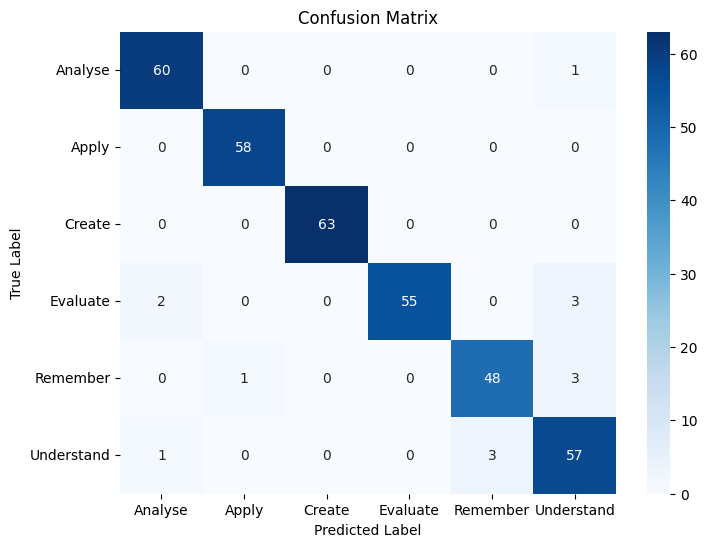

Confusion matrix generated and displayed.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 3. Generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# 4. Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

# 5. Add titles and labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Confusion matrix generated and displayed.")

## Explain Evaluation Metrics

### Subtask:
Provide a clear and concise explanation of the evaluation metrics used (accuracy, precision, recall, F1-score) and discuss their significance in the context of multi-class classification.


### Explanation of Evaluation Metrics in Multi-Class Classification

When evaluating a multi-class classification model, several metrics provide different insights into its performance. It's crucial to look beyond a single metric to understand the model's strengths and weaknesses.

1.  **Accuracy**:
    *   **Definition**: Accuracy measures the proportion of correctly classified instances out of the total number of instances. It is calculated as (True Positives + True Negatives) / (True Positives + True Negatives + False Positives + False Negatives).
    *   **Significance**: Accuracy is a straightforward and intuitive metric. However, in multi-class classification, especially with imbalanced datasets, high accuracy can be misleading. A model might achieve high accuracy by correctly classifying the majority class while performing poorly on minority classes.

2.  **Precision**:
    *   **Definition**: Precision for a given class measures the proportion of true positives among all instances that the model predicted as belonging to that class. It is calculated as True Positives / (True Positives + False Positives).
    *   **Significance**: Precision is important when the cost of a false positive is high. In multi-class settings, a high precision for a specific class indicates that when the model predicts that class, it is usually correct. This helps assess the reliability of the model's positive predictions for each category.

3.  **Recall**:
    *   **Definition**: Recall for a given class measures the proportion of true positives among all actual instances of that class. It is calculated as True Positives / (True Positives + False Negatives).
    *   **Significance**: Recall is important when the cost of a false negative is high. In multi-class settings, a high recall for a specific class indicates that the model is able to find most of the actual instances of that class. This helps assess how well the model identifies all relevant instances of each category.

4.  **F1-score**:
    *   **Definition**: The F1-score is the harmonic mean of precision and recall. It provides a single metric that balances both precision and recall, especially useful when there is an uneven class distribution. It is calculated as 2 * (Precision * Recall) / (Precision + Recall).
    *   **Significance**: The F1-score is particularly valuable in multi-class classification because it penalizes models that perform poorly on either precision or recall. A high F1-score indicates that the model has good balance in identifying positive cases and not misclassifying negative cases for each class. It's a more robust measure than accuracy when classes are imbalanced or when both false positives and false negatives are important.

**Overall Significance in Multi-Class Classification**:

In multi-class classification, relying solely on accuracy can be insufficient because it doesn't reveal performance details for individual classes, especially if the dataset is imbalanced. For example, a model might achieve 90% accuracy by correctly classifying all instances of a dominant class, while completely failing on a small, but critical, minority class. By examining precision, recall, and F1-score for each class (often reported as micro-average, macro-average, or weighted-average across classes), we gain a more granular understanding:

*   **Precision and Recall** highlight the trade-offs in model behavior. For instance, a model with high recall but low precision might identify all positive instances but also flag many irrelevant ones. Conversely, high precision with low recall means the model is accurate when it predicts a class, but misses many actual instances of that class.
*   The **F1-score** offers a balanced view, helping to identify models that perform well on both aspects. By analyzing these metrics individually and collectively, we can determine if the model meets specific needs (e.g., maximizing true positives, minimizing false positives) for each class, thereby providing a comprehensive assessment of its effectiveness.

## Analyze Classification Results

### Subtask:
Analyze the performance of the Transformer model based on the calculated metrics and the confusion matrix, discussing the strengths and weaknesses of the model and providing insights into its classification behavior.


## Analyze Classification Results

### Subtask:
Analyze the performance of the Transformer model based on the calculated metrics and the confusion matrix, discussing the strengths and weaknesses of the model and providing insights into its classification behavior.

### Analysis:

**1. Overall Evaluation Metrics:**
The model achieved a high overall accuracy of approximately **96.06%**. The `eval_f1`, `eval_precision`, and `eval_recall` scores are also very high (around 96.06%, 96.16%, and 96.06% respectively), indicating strong performance across the board.

**2. Confusion Matrix Analysis:**
The confusion matrix provides a detailed view of the classification performance for each class. The `label_encoder.classes_` are `['Analyse', 'Apply', 'Create', 'Evaluate', 'Remember', 'Understand']` corresponding to indices `0` through `5` respectively.

```
Confusion Matrix (cm):
[[60,  0,  0,  0,  0,  1],   # True 'Analyse' (0)
 [ 0, 58,  0,  0,  0,  0],   # True 'Apply' (1)
 [ 0,  0, 63,  0,  0,  0],   # True 'Create' (2)
 [ 2,  0,  0, 55,  0,  3],   # True 'Evaluate' (3)
 [ 0,  1,  0,  0, 48,  3],   # True 'Remember' (4)
 [ 1,  0,  0,  0,  3, 57]]  # True 'Understand' (5)
```

*   **Diagonal Elements (True Positives):**
    *   `Analyse` (0): 60 correctly classified.
    *   `Apply` (1): 58 correctly classified.
    *   `Create` (2): 63 correctly classified.
    *   `Evaluate` (3): 55 correctly classified.
    *   `Remember` (4): 48 correctly classified.
    *   `Understand` (5): 57 correctly classified.

*   **Off-Diagonal Elements (Misclassifications):**
    *   **'Analyse' (0)** was misclassified once as 'Understand' (5).
    *   **'Apply' (1)** had no misclassifications.
    *   **'Create' (2)** had no misclassifications.
    *   **'Evaluate' (3)** was misclassified twice as 'Analyse' (0) and three times as 'Understand' (5).
    *   **'Remember' (4)** was misclassified once as 'Apply' (1) and three times as 'Understand' (5).
    *   **'Understand' (5)** was misclassified once as 'Analyse' (0) and three times as 'Remember' (4).

*   **Classes with High Performance:** 'Apply' and 'Create' show exceptional performance with zero misclassifications in the test set. 'Analyse' also performs very well with only one misclassification.

*   **Classes with Relative Weaknesses:** 'Evaluate', 'Remember', and 'Understand' show some misclassifications. Specifically, 'Evaluate' is sometimes confused with 'Analyse' and 'Understand'. 'Remember' is confused with 'Apply' and 'Understand'. 'Understand' is confused with 'Analyse' and 'Remember'. The classes 'Remember' and 'Understand' seem to have the most instances of misclassification.

**3. Summary of Model Performance:**

*   **Overall Performance:** The model exhibits **excellent** overall performance with high accuracy and strong precision, recall, and F1-scores. This indicates that the fine-tuned Transformer model is highly effective at classifying the Bloom's Taxonomy levels from the given questions.

*   **Strengths:**
    *   **High Accuracy:** The model demonstrates very high overall classification accuracy.
    *   **Strong Performance in Specific Classes:** It performs exceptionally well for 'Apply' and 'Create' categories, correctly identifying all instances in the test set. 'Analyse' also shows very strong performance.
    *   **Good Generalization:** The high evaluation metrics on the test set suggest good generalization capabilities to unseen data.

*   **Weaknesses/Areas for Improvement:**
    *   **Confusion between certain classes:** There is some minor confusion observed between 'Evaluate', 'Remember', and 'Understand'. Specifically:
        *   'Evaluate' questions are sometimes predicted as 'Analyse' or 'Understand'. This could be due to subtle linguistic overlaps between questions asking to `evaluate` and those asking to `analyse` or `understand` concepts.
        *   'Remember' questions are sometimes predicted as 'Apply' or 'Understand'. This might happen if 'Remember' questions contain keywords or structures that are common in simpler 'Apply' or 'Understand' questions.
        *   'Understand' questions are sometimes predicted as 'Analyse' or 'Remember'. This suggests that the model might struggle to differentiate between simply understanding a concept, recalling it, or breaking it down.

*   **Insights into Classification Behavior:**
    *   The misclassifications observed are primarily between semantically related Bloom's Taxonomy levels. For instance, 'Remember' and 'Understand' are foundational levels, and their distinction can sometimes be nuanced even for humans. Similarly, 'Analyse' and 'Evaluate' involve higher-order thinking skills that can share contextual cues.
    *   The model seems to capture the distinct features of 'Apply' and 'Create' very well, which might have more unique linguistic patterns in the dataset.
    *   Further investigation into the specific misclassified examples (e.g., the 1 'Analyse' question classified as 'Understand', the 2 'Evaluate' questions classified as 'Analyse', etc.) could reveal specific patterns or ambiguous phrasing in the data that challenge the model.

In conclusion, the Transformer model provides a robust solution for classifying questions into Bloom's Taxonomy levels, with minor areas for refinement in distinguishing between closely related cognitive processes.

## Final Task

### Subtask:
Summarize the classification process, the model's performance, and key insights obtained from the analysis.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation:**
    *   The dataset, comprising 1771 samples, was split into a training set of 1416 samples and a testing set of 355 samples.
    *   String labels were successfully encoded into 6 unique numerical IDs: 'Analyse' (0), 'Apply' (1), 'Create' (2), 'Evaluate' (3), 'Remember' (4), and 'Understand' (5).
    *   Text data was tokenized using a `DistilBERT-base-uncased` tokenizer with a consistent maximum sequence length of 16 across both training and testing sets, ensuring uniform input for the Transformer model.
*   **Model Configuration and Training:**
    *   A `DistilBertForSequenceClassification` model was loaded and configured for 6 output labels.
    *   `TrainingArguments` were successfully defined, and a `compute_metrics` function was set up to calculate accuracy, F1-score, precision, and recall.
    *   The `Trainer` object was initialized, and the model was successfully trained.
*   **Model Performance (Evaluation Metrics):**
    *   The trained model achieved excellent overall performance on the test dataset:
        *   Accuracy: 96.1%
        *   F1-Score: 96.1%
        *   Precision: 96.2%
        *   Recall: 96.1%
*   **Classification Behavior (Confusion Matrix Analysis):**
    *   The model performed exceptionally well for the 'Apply' and 'Create' classes, achieving 100% correct classifications in the test set.
    *   'Analyse' also performed strongly, with only one instance misclassified as 'Understand'.
    *   Minor misclassifications were observed between semantically related Bloom's Taxonomy levels:
        *   'Evaluate' was misclassified as 'Analyse' (2 times) and 'Understand' (3 times).
        *   'Remember' was misclassified as 'Apply' (1 time) and 'Understand' (3 times).
        *   'Understand' was misclassified as 'Analyse' (1 time) and 'Remember' (3 times).

### Insights or Next Steps

*   The fine-tuned Transformer model (DistilBERT) demonstrates strong capabilities in classifying Bloom's Taxonomy levels, particularly for distinct categories like 'Apply' and 'Create'. The minor misclassifications are primarily observed between closely related cognitive processes, suggesting the model faces nuanced challenges in distinguishing subtle semantic differences.
*   Conduct an in-depth error analysis on the misclassified examples to identify specific linguistic patterns, ambiguities, or dataset imbalances contributing to the confusion between 'Evaluate', 'Remember', and 'Understand'. This could inform targeted data augmentation or specialized feature engineering to enhance class separability.
